<a href="https://colab.research.google.com/github/roshan-mahato/PRT_661_WILDFIRE_PREDICTION/blob/main/Machine_Learning_Model_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fire Occurrence Model Training + Accuracy Improvement

Takes the final labelled **daily fire-weather dataset** and trains a classifier to predict whether a fire detection occurs for each grid-cell/day.

**TARGET**
- `label = 1` → qualifying fire detection
- `label = 0` → sampled no-fire cell/day

**WHY THIS IS CLASSIFICATION**
The output is fire / no-fire, so the model is trained as a binary classifier rather than trying to predict FFDI itself.

**MODEL INPUTS**
The model uses the same 20-feature contract used by the shared wildfire prediction pipeline. The preprocessing pipeline supplies the daily weather / fire-danger variables, while `month_sin` and `month_cos` are added here from `acq_date`.

FIRMS detection fields such as brightness, FRP, confidence, satellite and instrument are not used as predictors because they would not be available before a fire is detected.

**MODEL OUTPUT**
- fire-risk score from `predict_proba()`
- binary prediction using the F1-optimal threshold selected from validation data

The saved model bundle follows the format used by the live prediction script: `model`, `model_name`, `features`, `scaler`, `threshold_default` and `threshold_f1_optimal`.

## 1. SETUP

Imports, random seed and output folder used by the training pipeline.


In [19]:
# ==============================================================================
# GOOGLE DRIVE
# ==============================================================================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
# ==============================================================================
# IMPORTS + CONFIG
# ==============================================================================
# In Colab, install these packages if they are not already available
# !pip -q install xgboost lightgbm imbalanced-learn shap joblib

# ---- Core Python / data ----
import json
import platform
from importlib.metadata import version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---- Models / evaluation ----
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    GradientBoostingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

import xgboost as xgb
import lightgbm as lgb
import shap

# ---- Reproducibility ----
RANDOM_STATE = 42
CV_FOLDS = 3
CV_MAX_ROWS = 25000
SHAP_ROWS = 100
SHAP_BACKGROUND_ROWS = 50

# ---- Project paths ----
FINAL_CSV = Path('/content/drive/MyDrive/firms_weather_cleaned_with_negatives.csv')
OUT_DIR = Path('/content/drive/MyDrive/fire_model_outputs')
OUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

## 2. LOAD TRAINING DATA

Loads `final.csv`, the labelled daily dataframe produced by the shared preprocessing and fire-danger feature pipeline.

In [21]:
# ==============================================================================
# LOAD LABELLED DAILY DATA
# ==============================================================================
# ---- 1. Mount Drive if needed ----
from pathlib import Path

if not Path('/content/drive/MyDrive').exists():
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Google Drive is already mounted.")

# ---- 2. Final labelled dataset from preprocessing ----
FINAL_CSV = '/content/drive/MyDrive/firms_weather_cleaned_with_negatives.csv'

assert Path(FINAL_CSV).exists(), (
    f'File not found: {FINAL_CSV}'
)

print('Loading:', FINAL_CSV)

# ---- 3. Load one row per grid-cell/day ----
df = pd.read_csv(FINAL_CSV)

print('Raw modelling dataframe shape:', df.shape)
display(df.head())

Google Drive is already mounted.
Loading: /content/drive/MyDrive/firms_weather_cleaned_with_negatives.csv
Raw modelling dataframe shape: (209793, 22)


,lat_round,lon_round,acq_date,temperature_2m,relative_humidity_2m,wind_speed_10m,wind_gusts_10m,wind_direction_10m,precipitation,soil_moisture_0_to_7cm,...,label,weather_outlier_flag,kbdi,drought_factor,days_since_rain,days_since_cell_start,kbdi_spinup_flag,emc,ffdi,rate_of_spread
0,-43.5,146.0,2024-05-10,12.410222,81.477038,8.248152,17.655999,105.361071,0.0,0.229356,...,1,False,0.201304,5.654105,1.0,0.0,True,18.280370,0.782331,0.007510
1,-43.5,146.0,2024-10-21,15.752474,79.673112,9.709290,22.727368,179.126520,0.0,0.243211,...,1,False,73.937803,9.655148,165.0,164.0,False,17.448899,1.635698,0.015703
2,-43.5,146.0,2025-08-11,10.022000,72.773119,8.766971,20.448000,98.059778,0.0,0.242200,...,1,False,96.476722,10.000000,459.0,458.0,False,15.113268,1.731550,0.016623
3,-43.5,146.5,2024-11-11,8.808064,63.002205,11.854714,36.350769,222.728996,0.0,0.254949,...,1,False,0.020848,5.644313,1.0,0.0,True,12.512804,1.423095,0.013662
4,-43.5,146.5,2025-03-19,15.729990,57.477324,7.872270,31.305305,162.541743,0.0,0.273673,...,1,True,46.211935,8.150704,129.0,128.0,False,11.355945,2.848787,0.027348


## 3. TARGET + DATA CHECKS

Checks the binary target, dates, KBDI spin-up flag and duplicate grid-cell/day records before model training.

In [22]:
# ==============================================================================
# TARGET + DATA VALIDATION
# ==============================================================================
# ---- 1. Validate binary target ----
assert 'label' in df.columns, "Target column 'label' is missing"

df['label'] = pd.to_numeric(df['label'], errors='coerce')
df = df[df['label'].isin([0, 1])].copy()
df['label'] = df['label'].astype(int)

assert set(df['label'].unique()) == {0, 1}, 'Both fire (1) and no-fire (0) rows are required'

# ---- 2. Parse acquisition date ----
assert 'acq_date' in df.columns, 'acq_date is required for the monthly cyclical features'
df['acq_date'] = pd.to_datetime(df['acq_date'], errors='coerce')
df = df[df['acq_date'].notna()].copy()

# ---- 3. Keep KBDI spin-up rows to match the shared training/live pipeline ----
if 'kbdi_spinup_flag' in df.columns:
    spinup = df['kbdi_spinup_flag']
    if spinup.dtype != bool:
        spinup = spinup.astype(str).str.lower().eq('true')
    print('KBDI spin-up rows:', int(spinup.sum()))

# ---- 4. Class balance ----
class_counts = df['label'].value_counts().sort_index()
class_summary = pd.DataFrame({
    'class': ['No fire (0)', 'Fire (1)'],
    'rows': [class_counts.get(0, 0), class_counts.get(1, 0)]
})
class_summary['percent'] = 100 * class_summary['rows'] / class_summary['rows'].sum()

display(class_summary)
print('Rows after validation:', len(df))
print('Date range:', df['acq_date'].min(), 'to', df['acq_date'].max())

KBDI spin-up rows: 12920


,class,rows,percent
0,No fire (0),70521,33.614563
1,Fire (1),139272,66.385437


Rows after validation: 209793
Date range: 2024-01-01 00:00:00 to 2026-08-25 00:00:00


In [23]:
# ==============================================================================
# DUPLICATE + CLASS CHECKS
# ==============================================================================
duplicate_cell_days = int(
    df.duplicated(['lat_round', 'lon_round', 'acq_date']).sum()
)
print('Duplicate grid-cell/day rows:', duplicate_cell_days)

assert duplicate_cell_days == 0, (
    'Duplicate grid-cell/day rows found. Resolve these in the preprocessing pipeline before modelling.'
)

assert df['label'].value_counts().min() >= 30, (
    'Too few observations in one class for stratified splitting and SMOTE.'
)

Duplicate grid-cell/day rows: 0


## 4. MODEL FEATURES
The preprocessing pipeline already supplies the weather, drought-state and fire-danger variables. `month_sin` and `month_cos` are added from `acq_date`. Raw `wind_direction_10m`, `days_since_cell_start` and `rate_of_spread` are retained so the training feature contract matches live inference.

In [24]:
# ==============================================================================
# BUILD MODEL FEATURES
# ==============================================================================
# ---- 1. Monthly cyclical features used by the shared live pipeline ----
df['month'] = df['acq_date'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# ---- 2. Exact deployment feature contract ----
FEATURES = [
    'wind_gusts_10m',
    'soil_moisture_0_to_7cm',
    'temperature_2m',
    'et0_fao_evapotranspiration',
    'days_since_cell_start',
    'wind_speed_10m',
    'wind_direction_10m',
    'emc',
    'relative_humidity_2m',
    'vapour_pressure_deficit',
    'rate_of_spread',
    'ffdi',
    'precipitation',
    'month_cos',
    'days_since_rain',
    'kbdi',
    'drought_factor',
    'month_sin',
    'lat_round',
    'lon_round',
]

assert len(FEATURES) == 20, 'The shared model contract requires exactly 20 features'

missing_features = [c for c in FEATURES if c not in df.columns]
assert not missing_features, f'Missing required model features: {missing_features}'

# ---- 3. Block FIRMS detection-only leakage ----
FIRMS_ONLY_FIELDS = {
    'brightness', 'bright_ti4', 'bright_ti5', 'frp', 'confidence', 'type',
    'satellite', 'instrument', 'scan', 'track', 'acq_time'
}
assert not (set(FEATURES) & FIRMS_ONLY_FIELDS), (
    'A FIRMS-only field has leaked into the predictor list.'
)

# ---- 4. Final X / y ----
X = df[FEATURES].copy()
y = df['label'].copy()

print('Number of model features:', len(FEATURES))
print(FEATURES)

Number of model features: 20
['wind_gusts_10m', 'soil_moisture_0_to_7cm', 'temperature_2m', 'et0_fao_evapotranspiration', 'days_since_cell_start', 'wind_speed_10m', 'wind_direction_10m', 'emc', 'relative_humidity_2m', 'vapour_pressure_deficit', 'rate_of_spread', 'ffdi', 'precipitation', 'month_cos', 'days_since_rain', 'kbdi', 'drought_factor', 'month_sin', 'lat_round', 'lon_round']


## 5. TRAIN / VALIDATION / TEST SPLIT

60% training, 20% validation, 20% test.

The split is stratified so the fire/no-fire ratio stays similar in all three sets. Validation is used for model selection and threshold optimisation; test data stays untouched until the final check.

In [25]:
# ==============================================================================
# STRATIFIED DATA SPLIT
# ==============================================================================
# ---- 1. 60% train / 40% temporary holdout ----
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE,
)

# ---- 2. Split holdout evenly -> 20% validation / 20% test ----
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

for name, yy in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'{name}: {len(yy):,} rows | fire rate = {yy.mean():.2%}')

Train: 125,875 rows | fire rate = 66.39%
Validation: 41,959 rows | fire rate = 66.38%
Test: 41,959 rows | fire rate = 66.39%


In [26]:
# ==============================================================================
# SPLIT CHECKS
# ==============================================================================
assert set(X_train.index).isdisjoint(X_val.index)
assert set(X_train.index).isdisjoint(X_test.index)
assert set(X_val.index).isdisjoint(X_test.index)

split_records = df[['acq_date', 'lat_round', 'lon_round', 'label']].copy()
split_records['split'] = ''

for split_name, indices in [
    ('train', X_train.index),
    ('validation', X_val.index),
    ('test', X_test.index),
]:
    split_records.loc[indices, 'split'] = split_name

split_records.to_csv(
    OUT_DIR / 'split_membership.csv',
    index_label='source_row',
)
print('Split overlap check passed.')

Split overlap check passed.


## 6. MODEL DEFINITIONS

Models compared:
- Dummy baseline
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- HistGradientBoosting
- XGBoost
- LightGBM
- GradientBoostingClassifier

The real classifiers use the same class-imbalance strategy and tuned configurations used by the shared modelling workflow. SMOTE is checked separately for Logistic Regression and Random Forest.

In [29]:
# ==============================================================================
# DEFINE CANDIDATE MODELS
# ==============================================================================
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / positive_count

models = {
    'Dummy': DummyClassifier(
        strategy='most_frequent',
        random_state=RANDOM_STATE,
    ),

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(
            C=1.0,
            class_weight='balanced',
            max_iter=2000,
            random_state=RANDOM_STATE,
        )),
    ]),

    'Decision Tree': DecisionTreeClassifier(
        criterion='gini',
        max_depth=None,
        min_samples_leaf=100,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=150,
        max_depth=None,
        min_samples_leaf=2,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        max_iter=150,
        max_depth=6,
        learning_rate=0.10,
        l2_regularization=0,
        class_weight='balanced',
        random_state=RANDOM_STATE,
    ),

    'XGBoost': xgb.XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.10,
        subsample=0.80,
        colsample_bytree=1.0,
        min_child_weight=1,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        tree_method='hist',
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),

    'LightGBM': lgb.LGBMClassifier(
        n_estimators=300,
        num_leaves=63,
        min_child_samples=30,
        learning_rate=0.05,
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=1,
        verbosity=-1,
    ),

    'Gradient Boosting': GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE,
    ),
}

real_classifier_names = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Extra Trees',
    'Gradient Boosting',
    'HistGradientBoosting',
    'XGBoost',
    'LightGBM',
]

print('Classifier families:', real_classifier_names)
print('scale_pos_weight:', round(scale_pos_weight, 4))

Classifier families: ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Extra Trees', 'Gradient Boosting', 'HistGradientBoosting', 'XGBoost', 'LightGBM']
scale_pos_weight: 0.5063


## 7. EVALUATION + CROSS-VALIDATION

Metrics used: Accuracy, Balanced Accuracy, Precision, Recall, F1, ROC-AUC and PR-AUC.

The 8 classifier families are benchmarked using 3-fold stratified cross-validation on a 25,000-row stratified subset of the training data for runtime efficiency. Final candidate models are then fitted using the complete training split.

Class weighting is the default imbalance strategy. Unweighted and SMOTE alternatives are also compared for Logistic Regression and Random Forest.

In [30]:
# ==============================================================================
# METRICS + IMBALANCE CHECK
# ==============================================================================
def evaluate_scores(y_true, scores, threshold=0.50):
    pred = (scores >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()

    return {
        'threshold': float(threshold),
        'accuracy': accuracy_score(y_true, pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'precision_fire': precision_score(y_true, pred, zero_division=0),
        'recall_fire': recall_score(y_true, pred, zero_division=0),
        'f1_fire': f1_score(y_true, pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, scores),
        'pr_auc': average_precision_score(y_true, scores),
        'tn': int(tn),
        'fp': int(fp),
        'fn': int(fn),
        'tp': int(tp),
    }

# ---- 1. Unweighted controls ----
logistic_unweighted = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        C=1.0,
        class_weight=None,
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

rf_unweighted = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_leaf=2,
    max_features='sqrt',
    class_weight=None,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

# ---- 2. SMOTE applied to training rows only ----
logistic_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('model', LogisticRegression(
        C=1.0,
        class_weight=None,
        max_iter=2000,
        random_state=RANDOM_STATE,
    )),
])

rf_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        max_depth=16,
        class_weight=None,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])

imbalance_models = {
    'Logistic Regression - unweighted': logistic_unweighted,
    'Logistic Regression - class weight': clone(models['Logistic Regression']),
    'Logistic Regression - SMOTE': logistic_smote,
    'Random Forest - unweighted': rf_unweighted,
    'Random Forest - class weight': clone(models['Random Forest']),
    'Random Forest - SMOTE': rf_smote,
}

imbalance_rows = []

for name, model in imbalance_models.items():
    print('Imbalance check:', name)
    model.fit(X_train, y_train)
    scores = model.predict_proba(X_val)[:, 1]
    row = evaluate_scores(y_val, scores, 0.50)
    row['model'] = name
    imbalance_rows.append(row)

imbalance_results = pd.DataFrame(imbalance_rows).sort_values(
    ['roc_auc', 'balanced_accuracy'],
    ascending=False,
).reset_index(drop=True)

display(imbalance_results.round(4))
imbalance_results.to_csv(
    OUT_DIR / 'imbalance_handling_comparison.csv',
    index=False,
)

print('Training class counts:')
print(y_train.value_counts().sort_index())

# ==============================================================================
# STRATIFIED CROSS-VALIDATION BENCHMARK
# ==============================================================================
if CV_MAX_ROWS is not None and len(X_train) > CV_MAX_ROWS:
    X_cv, _, y_cv, _ = train_test_split(
        X_train,
        y_train,
        train_size=CV_MAX_ROWS,
        stratify=y_train,
        random_state=RANDOM_STATE,
    )
else:
    X_cv, y_cv = X_train, y_train

cv = StratifiedKFold(
    n_splits=CV_FOLDS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_fold_rows = []

for name in real_classifier_names:
    print('Cross-validation:', name, '| rows:', len(X_cv))

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv, y_cv), start=1):
        model = clone(models[name])

        X_fold_train = X_cv.iloc[train_idx]
        y_fold_train = y_cv.iloc[train_idx]
        X_fold_valid = X_cv.iloc[valid_idx]
        y_fold_valid = y_cv.iloc[valid_idx]

        model.fit(X_fold_train, y_fold_train)
        fold_scores = model.predict_proba(X_fold_valid)[:, 1]
        fold_metrics = evaluate_scores(y_fold_valid, fold_scores, 0.50)

        cv_fold_rows.append({
            'model': name,
            'fold': fold,
            'roc_auc': fold_metrics['roc_auc'],
            'average_precision': fold_metrics['pr_auc'],
            'balanced_accuracy': fold_metrics['balanced_accuracy'],
            'accuracy': fold_metrics['accuracy'],
            'f1': fold_metrics['f1_fire'],
        })

cv_fold_results = pd.DataFrame(cv_fold_rows)

cv_results = (
    cv_fold_results
    .groupby('model')
    .agg(
        cv_rows=('fold', lambda x: len(X_cv)),
        folds=('fold', 'count'),
        roc_auc_mean=('roc_auc', 'mean'),
        roc_auc_sd=('roc_auc', 'std'),
        average_precision_mean=('average_precision', 'mean'),
        average_precision_sd=('average_precision', 'std'),
        balanced_accuracy_mean=('balanced_accuracy', 'mean'),
        balanced_accuracy_sd=('balanced_accuracy', 'std'),
        accuracy_mean=('accuracy', 'mean'),
        accuracy_sd=('accuracy', 'std'),
        f1_mean=('f1', 'mean'),
        f1_sd=('f1', 'std'),
    )
    .reset_index()
    .sort_values('roc_auc_mean', ascending=False)
    .reset_index(drop=True)
)

display(cv_results.round(4))
cv_results.to_csv(
    OUT_DIR / 'cross_validation_summary.csv',
    index=False,
)
cv_fold_results.to_csv(
    OUT_DIR / 'cross_validation_folds.csv',
    index=False,
)

Imbalance check: Logistic Regression - unweighted
Imbalance check: Logistic Regression - class weight
Imbalance check: Logistic Regression - SMOTE
Imbalance check: Random Forest - unweighted
Imbalance check: Random Forest - class weight
Imbalance check: Random Forest - SMOTE


,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp,model
0,0.5,0.8456,0.8165,0.8678,0.9053,0.8862,0.9348,0.9692,10265,3840,2638,25216,Random Forest - unweighted
1,0.5,0.8457,0.8250,0.8804,0.8882,0.8843,0.9348,0.9693,10744,3361,3113,24741,Random Forest - class weight
2,0.5,0.8244,0.8419,0.9371,0.7883,0.8563,0.9253,0.9646,12631,1474,5896,21958,Random Forest - SMOTE
3,0.5,0.7187,0.6569,0.7584,0.8457,0.7997,0.7854,0.8919,6602,7503,4299,23555,Logistic Regression - unweighted
4,0.5,0.6953,0.7134,0.8490,0.6580,0.7414,0.7833,0.8949,10844,3261,9526,18328,Logistic Regression - SMOTE
5,0.5,0.6952,0.7138,0.8497,0.6571,0.7411,0.7833,0.8951,10867,3238,9552,18302,Logistic Regression - class weight


Training class counts:
label
0    42312
1    83563
Name: count, dtype: int64
Cross-validation: Logistic Regression | rows: 25000
Cross-validation: Decision Tree | rows: 25000
Cross-validation: Random Forest | rows: 25000
Cross-validation: Extra Trees | rows: 25000
Cross-validation: Gradient Boosting | rows: 25000
Cross-validation: HistGradientBoosting | rows: 25000
Cross-validation: XGBoost | rows: 25000
Cross-validation: LightGBM | rows: 25000


,model,cv_rows,folds,roc_auc_mean,roc_auc_sd,average_precision_mean,average_precision_sd,balanced_accuracy_mean,balanced_accuracy_sd,accuracy_mean,accuracy_sd,f1_mean,f1_sd
0,XGBoost,25000,3,0.9249,0.0051,0.9644,0.0022,0.8379,0.0062,0.8282,0.0069,0.8619,0.0060
1,LightGBM,25000,3,0.9248,0.0046,0.9642,0.0020,0.8358,0.0089,0.8322,0.0103,0.8670,0.0090
2,HistGradientBoosting,25000,3,0.9216,0.0047,0.9624,0.0021,0.8364,0.0043,0.8204,0.0050,0.8534,0.0047
3,Random Forest,25000,3,0.9156,0.0033,0.9593,0.0016,0.7869,0.0025,0.8226,0.0030,0.8702,0.0024
4,Extra Trees,25000,3,0.9072,0.0019,0.9540,0.0008,0.7929,0.0041,0.8186,0.0031,0.8644,0.0022
5,Gradient Boosting,25000,3,0.8990,0.0038,0.9502,0.0021,0.7496,0.0077,0.8042,0.0060,0.8613,0.0040
6,Decision Tree,25000,3,0.8817,0.0039,0.9391,0.0024,0.7872,0.0088,0.7709,0.0064,0.8104,0.0051
7,Logistic Regression,25000,3,0.7798,0.0034,0.8925,0.0023,0.7058,0.0028,0.6903,0.0047,0.7384,0.0055


## 8. TRAIN + VALIDATE

Fits every candidate on the complete training split and compares them on the validation set at the default 0.50 threshold. The final model family is selected by validation ROC-AUC, matching the shared modelling workflow.

In [31]:
# ==============================================================================
# TRAIN + VALIDATION COMPARISON
# ==============================================================================
fitted_models = {}
validation_rows = []

for name, model in models.items():
    print('Training:', name)
    model.fit(X_train, y_train)
    fitted_models[name] = model

    val_scores = model.predict_proba(X_val)[:, 1]
    row = evaluate_scores(y_val, val_scores, 0.50)
    row['model'] = name
    validation_rows.append(row)

validation_results = pd.DataFrame(validation_rows).sort_values(
    ['roc_auc', 'pr_auc'],
    ascending=False,
).reset_index(drop=True)

display(validation_results.round(4))
validation_results.to_csv(
    OUT_DIR / 'model_comparison_validation.csv',
    index=False,
)

Training: Dummy
Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: Extra Trees
Training: HistGradientBoosting
Training: XGBoost
Training: LightGBM
Training: Gradient Boosting


,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp,model
0,0.5,0.8372,0.8632,0.9643,0.7837,0.8647,0.9376,0.9709,13296,809,6024,21830,LightGBM
1,0.5,0.8330,0.8594,0.9625,0.7787,0.8609,0.9351,0.9696,13260,845,6163,21691,XGBoost
2,0.5,0.8457,0.8250,0.8804,0.8882,0.8843,0.9348,0.9693,10744,3361,3113,24741,Random Forest
3,0.5,0.8214,0.8498,0.9595,0.7631,0.8501,0.9296,0.9669,13208,897,6598,21256,HistGradientBoosting
4,0.5,0.8418,0.8292,0.8911,0.8676,0.8792,0.9296,0.9662,11153,2952,3688,24166,Extra Trees
5,0.5,0.7977,0.8186,0.9269,0.7547,0.8320,0.9050,0.9529,12447,1658,6832,21022,Decision Tree
6,0.5,0.8055,0.7506,0.8130,0.9183,0.8625,0.9022,0.9525,8221,5884,2275,25579,Gradient Boosting
7,0.5,0.6952,0.7138,0.8497,0.6571,0.7411,0.7833,0.8951,10867,3238,9552,18302,Logistic Regression
8,0.5,0.6638,0.5000,0.6638,1.0000,0.7980,0.5000,0.6638,0,14105,0,27854,Dummy


## 9. THRESHOLD + CALIBRATION CHECK

Selects the leading real model from validation ROC-AUC, finds its F1-optimal validation threshold, checks the precision/recall trade-off, and compares calibration across the leading models.

Selected model: LightGBM
F1-optimal threshold: 0.34


,setting,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp
0,Default 0.50,0.50,0.8372,0.8632,0.9643,0.7837,0.8647,0.9376,0.9709,13296,809,6024,21830
1,F1-optimal,0.34,0.8480,0.8271,0.8815,0.8909,0.8861,0.9376,0.9709,10768,3337,3040,24814


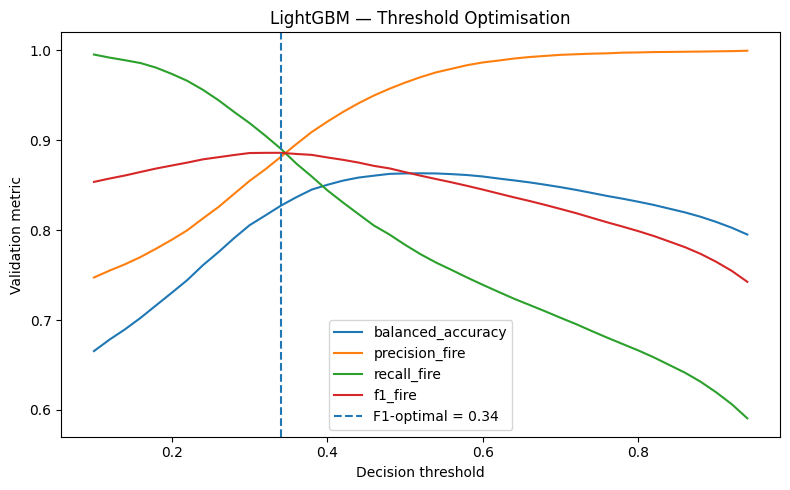

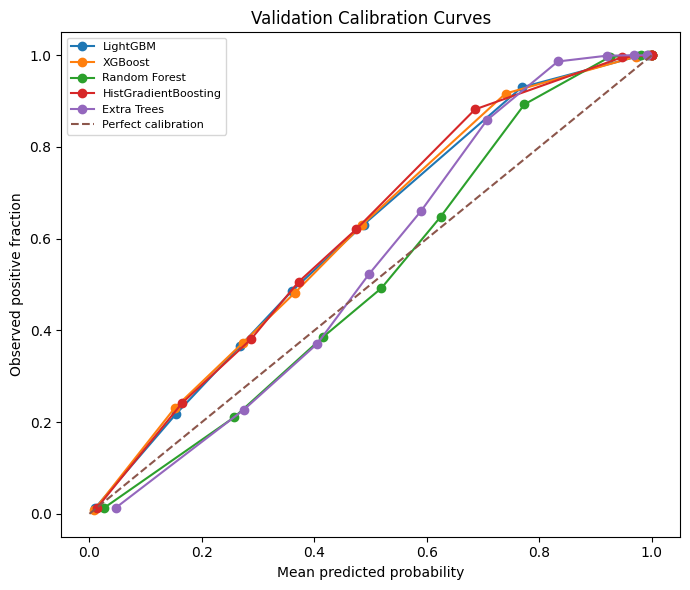

,model,brier_score,log_loss
0,Random Forest,0.1004,0.3058
1,LightGBM,0.1029,0.3028
2,XGBoost,0.1054,0.3092
3,Extra Trees,0.1086,0.3398
4,HistGradientBoosting,0.1107,0.3242


In [32]:
# ==============================================================================
# SELECT MODEL + OPTIMISE THRESHOLD
# ==============================================================================
real_models = validation_results[
    validation_results['model'] != 'Dummy'
].copy()

best_name = real_models.iloc[0]['model']
best_model = fitted_models[best_name]

val_scores = best_model.predict_proba(X_val)[:, 1]

# ---- 1. F1-optimal threshold used by the live prediction bundle ----
threshold_grid = np.arange(0.10, 0.95, 0.02)
threshold_rows = []

for threshold in threshold_grid:
    row = evaluate_scores(y_val, val_scores, threshold)
    threshold_rows.append(row)

threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.loc[
    threshold_results['f1_fire'].idxmax()
]
best_threshold = float(best_threshold_row['threshold'])

print('Selected model:', best_name)
print('F1-optimal threshold:', round(best_threshold, 4))

comparison = pd.DataFrame([
    {'setting': 'Default 0.50', **evaluate_scores(y_val, val_scores, 0.50)},
    {'setting': 'F1-optimal', **evaluate_scores(y_val, val_scores, best_threshold)},
])
display(comparison.round(4))

threshold_results.to_csv(
    OUT_DIR / 'threshold_optimization.csv',
    index=False,
)

# ---- 2. Threshold trade-off plot ----
fig, ax = plt.subplots(figsize=(8, 5))

for metric in [
    'balanced_accuracy',
    'precision_fire',
    'recall_fire',
    'f1_fire',
]:
    ax.plot(
        threshold_results['threshold'],
        threshold_results[metric],
        label=metric,
    )

ax.axvline(
    best_threshold,
    linestyle='--',
    label=f'F1-optimal = {best_threshold:.2f}',
)
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Validation metric')
ax.set_title(f'{best_name} — Threshold Optimisation')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'threshold_optimization.png', dpi=180)
plt.show()

# ---- 3. Calibration check for the five leading models ----
top_names = real_models['model'].head(5).tolist()
calibration_rows = []
reliability_rows = []

fig, ax = plt.subplots(figsize=(7, 6))

for name in top_names:
    scores = fitted_models[name].predict_proba(X_val)[:, 1]

    observed, predicted = calibration_curve(
        y_val,
        scores,
        n_bins=10,
        strategy='quantile',
    )

    ax.plot(predicted, observed, marker='o', label=name)

    calibration_rows.append({
        'model': name,
        'brier_score': brier_score_loss(y_val, scores),
        'log_loss': log_loss(y_val, scores, labels=[0, 1]),
    })

    for i, (predicted_score, observed_fraction) in enumerate(
        zip(predicted, observed)
    ):
        reliability_rows.append({
            'model': name,
            'bin': i + 1,
            'mean_score': predicted_score,
            'observed_fraction': observed_fraction,
        })

ax.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
ax.set_xlabel('Mean predicted probability')
ax.set_ylabel('Observed positive fraction')
ax.set_title('Validation Calibration Curves')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR / 'calibration_curves.png', dpi=180)
plt.show()

calibration_results = pd.DataFrame(calibration_rows).sort_values(
    'brier_score'
).reset_index(drop=True)

display(calibration_results.round(4))
calibration_results.to_csv(
    OUT_DIR / 'calibration_metrics.csv',
    index=False,
)

pd.DataFrame(reliability_rows).to_csv(
    OUT_DIR / 'calibration_bins.csv',
    index=False,
)

## 10. FINAL TEST EVALUATION

Evaluates the validation-selected model once on the untouched test set. Results are shown at both the default 0.50 threshold and the F1-optimal threshold used by live prediction.

In [33]:
# ==============================================================================
# FINAL TEST EVALUATION
# ==============================================================================
test_scores = best_model.predict_proba(X_test)[:, 1]

test_default = evaluate_scores(y_test, test_scores, 0.50)
test_optimised = evaluate_scores(y_test, test_scores, best_threshold)

test_results = pd.DataFrame([
    {'model': best_name, 'setting': 'Default 0.50', **test_default},
    {'model': best_name, 'setting': 'F1-optimal', **test_optimised},
])

display(test_results.round(4))
test_results.to_csv(
    OUT_DIR / 'final_test_metrics.csv',
    index=False,
)

# Live deployment uses the validation-selected F1 threshold
test_metrics = test_optimised
print('Selected model:', best_name)
print('Deployment threshold:', round(best_threshold, 4))

,model,setting,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp
0,LightGBM,Default 0.50,0.50,0.8369,0.8639,0.9663,0.7815,0.8641,0.9362,0.9704,13346,758,6087,21768
1,LightGBM,F1-optimal,0.34,0.8459,0.8259,0.8817,0.8869,0.8843,0.9362,0.9704,10789,3315,3151,24704


Selected model: LightGBM
Deployment threshold: 0.34


## 11. EVALUATION CURVES

Confusion matrix at the deployment threshold, plus ROC and Precision-Recall curves for the selected model.

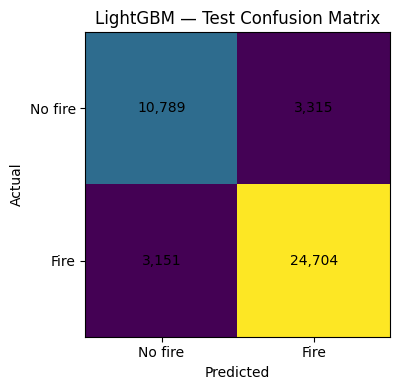

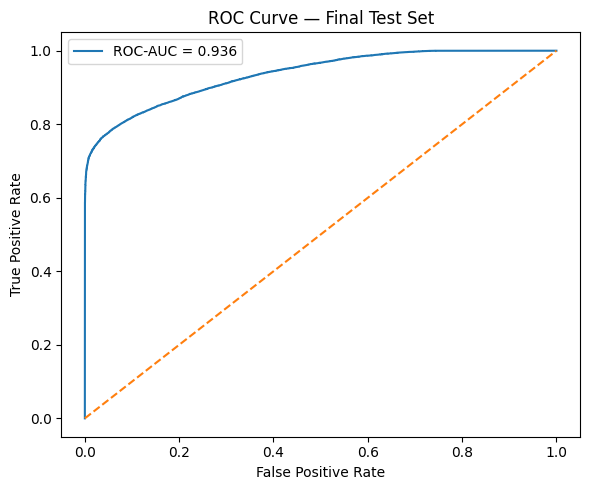

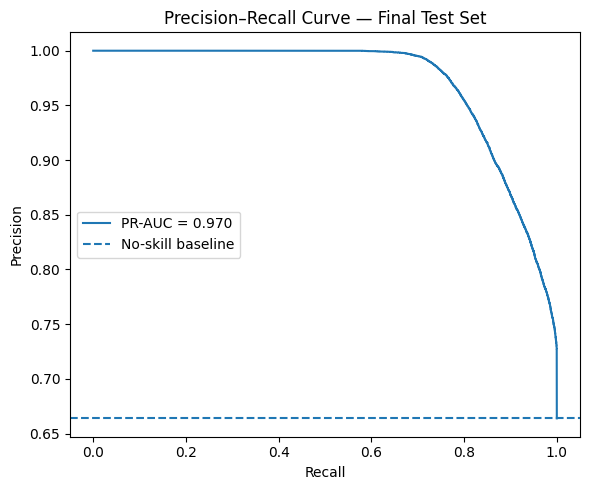

In [34]:
# ==============================================================================
# CONFUSION MATRIX + ROC / PR CURVES
# ==============================================================================
# ---- 1. Confusion matrix ----
test_pred = (test_scores >= best_threshold).astype(int)
cm = confusion_matrix(y_test, test_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ax.imshow(cm)
for (i, j), value in np.ndenumerate(cm):
    ax.text(j, i, f'{value:,}', ha='center', va='center')
ax.set_xticks([0, 1], ['No fire', 'Fire'])
ax.set_yticks([0, 1], ['No fire', 'Fire'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'{best_name} — Test Confusion Matrix')
plt.tight_layout()
plt.savefig(OUT_DIR / 'confusion_matrix.png', dpi=180)
plt.show()

# ---- 2. ROC curve ----
fpr, tpr, _ = roc_curve(y_test, test_scores)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    fpr,
    tpr,
    label=f'ROC-AUC = {roc_auc_score(y_test, test_scores):.3f}',
)
ax.plot([0, 1], [0, 1], linestyle='--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Final Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'roc_curve.png', dpi=180)
plt.show()

# ---- 3. Precision-Recall curve ----
precision, recall, _ = precision_recall_curve(y_test, test_scores)
fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(
    recall,
    precision,
    label=f'PR-AUC = {average_precision_score(y_test, test_scores):.3f}',
)
ax.axhline(y_test.mean(), linestyle='--', label='No-skill baseline')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision–Recall Curve — Final Test Set')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'precision_recall_curve.png', dpi=180)
plt.show()

## 12. FEATURE IMPORTANCE + SHAP

Native feature importance and SHAP are used to explain the selected model. These values describe model behaviour and should not be interpreted as proof of causation.

,feature,importance
3,et0_fao_evapotranspiration,3387
9,vapour_pressure_deficit,1542
5,wind_speed_10m,1515
4,days_since_cell_start,1317
13,month_cos,1283
6,wind_direction_10m,990
18,lat_round,986
2,temperature_2m,980
10,rate_of_spread,876
15,kbdi,759


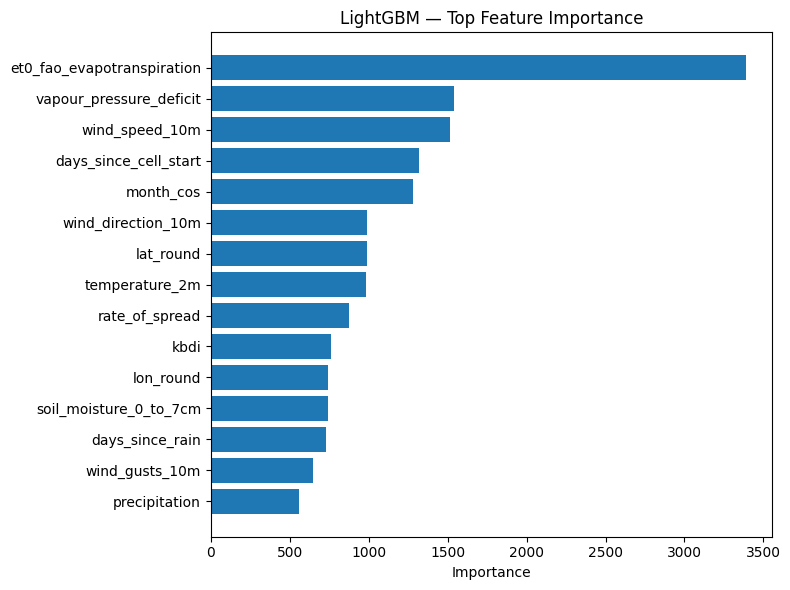

,feature,mean_absolute_shap
0,et0_fao_evapotranspiration,2.744144
1,days_since_cell_start,0.929707
2,month_cos,0.387023
3,vapour_pressure_deficit,0.322549
4,wind_speed_10m,0.277089
5,days_since_rain,0.187881
6,lat_round,0.165185
7,precipitation,0.154628
8,lon_round,0.125243
9,rate_of_spread,0.120269


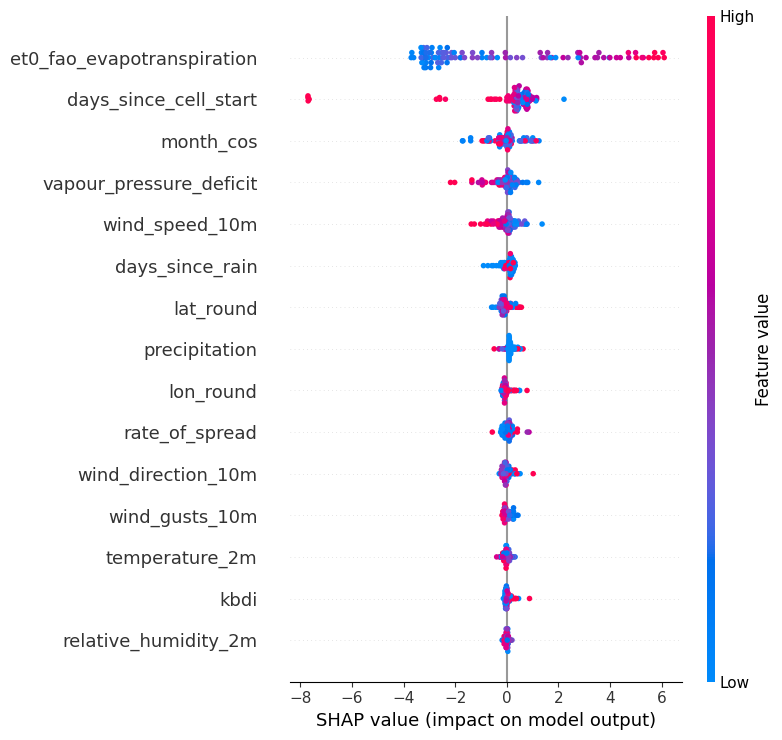

In [35]:
# ==============================================================================
# FEATURE IMPORTANCE
# ==============================================================================
if hasattr(best_model, 'feature_importances_'):
    importance = pd.DataFrame({
        'feature': FEATURES,
        'importance': best_model.feature_importances_,
    }).sort_values('importance', ascending=False)

    display(importance.head(15))
    importance.to_csv(
        OUT_DIR / 'feature_importance.csv',
        index=False,
    )

    top = importance.head(15).sort_values('importance')
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top['feature'], top['importance'])
    ax.set_xlabel('Importance')
    ax.set_title(f'{best_name} — Top Feature Importance')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'feature_importance.png', dpi=180)
    plt.show()
else:
    print('Native feature importance is not available for the selected model.')

# ==============================================================================
# SHAP EXPLAINABILITY
# ==============================================================================
X_shap = X_val.sample(
    min(SHAP_ROWS, len(X_val)),
    random_state=RANDOM_STATE,
)

try:
    if best_name == 'Logistic Regression':
        background = X_train.sample(
            min(SHAP_BACKGROUND_ROWS, len(X_train)),
            random_state=RANDOM_STATE,
        )

        def predict_for_shap(values):
            frame = pd.DataFrame(values, columns=FEATURES)
            return best_model.predict_proba(frame)[:, 1]

        explainer = shap.Explainer(
            predict_for_shap,
            background,
            algorithm='permutation',
            feature_names=FEATURES,
            seed=RANDOM_STATE,
        )
        shap_values = explainer(
            X_shap,
            max_evals=3 * (2 * len(FEATURES) + 1),
        )
    else:
        explainer = shap.Explainer(best_model, X_train.sample(
            min(SHAP_BACKGROUND_ROWS, len(X_train)),
            random_state=RANDOM_STATE,
        ))
        shap_values = explainer(X_shap)

    values = shap_values.values
    if values.ndim == 3:
        values = values[:, :, 1]

    shap_importance = pd.DataFrame({
        'feature': FEATURES,
        'mean_absolute_shap': np.abs(values).mean(axis=0),
    }).sort_values(
        'mean_absolute_shap',
        ascending=False,
    ).reset_index(drop=True)

    display(shap_importance.head(15))
    shap_importance.to_csv(
        OUT_DIR / 'shap_global_importance.csv',
        index=False,
    )

    pd.DataFrame(
        values,
        columns=FEATURES,
        index=X_shap.index,
    ).to_csv(
        OUT_DIR / 'shap_values.csv',
        index_label='source_row',
    )

    shap.summary_plot(
        values,
        X_shap,
        show=False,
        max_display=15,
    )
    plt.tight_layout()
    plt.savefig(
        OUT_DIR / 'shap_summary.png',
        dpi=180,
        bbox_inches='tight',
    )
    plt.show()
except Exception as error:
    print('SHAP failed:', error)

## 13. TEST PREDICTIONS + ERROR ANALYSIS

Stores row-level fire-risk scores and predicted labels at the deployment threshold, then compares false positives and false negatives with correctly classified observations. Monthly and grid-cell summaries are saved for later checking.

In [36]:
# ==============================================================================
# SAVE ROW-LEVEL TEST PREDICTIONS
# ==============================================================================
prediction_output = df.loc[
    X_test.index,
    ['acq_date', 'lat_round', 'lon_round', 'label'],
].copy()

prediction_output['fire_probability'] = test_scores
prediction_output['fire_predicted'] = test_pred
prediction_output['risk_level'] = pd.cut(
    test_scores,
    bins=[-0.01, 0.25, 0.50, 0.75, 1.01],
    labels=['Low', 'Moderate', 'High', 'Extreme'],
)

prediction_output.to_csv(
    OUT_DIR / 'test_predictions.csv',
    index=False,
)
display(prediction_output.head(10))

error_output = prediction_output.copy()
error_output['error_type'] = np.select(
    [
        (y_test == 1) & (test_pred == 1),
        (y_test == 0) & (test_pred == 0),
        (y_test == 0) & (test_pred == 1),
    ],
    ['TP', 'TN', 'FP'],
    default='FN',
)

error_output.to_csv(
    OUT_DIR / 'test_predictions_with_errors.csv',
    index_label='source_row',
)

# ---- 1. Feature profiles ----
error_features = X_test.copy()
error_features['error_type'] = error_output['error_type']

error_profile = (
    error_features
    .groupby('error_type')[FEATURES]
    .mean()
    .reindex(['TN', 'FP', 'TP', 'FN'])
    .T
)

error_profile['overall_mean'] = X_test.mean()
error_profile['FP_minus_TN'] = error_profile['FP'] - error_profile['TN']
error_profile['FN_minus_TP'] = error_profile['FN'] - error_profile['TP']

display(error_profile.round(3))
error_profile.to_csv(
    OUT_DIR / 'error_feature_profiles.csv',
    index_label='feature',
)

# ---- 2. Monthly + grid-cell summaries ----
summary_input = error_output.copy()
summary_input['month'] = pd.to_datetime(
    summary_input['acq_date']
).dt.month

for label_name in ['TP', 'TN', 'FP', 'FN']:
    summary_input[label_name] = (
        summary_input['error_type'] == label_name
    ).astype(int)


def build_error_summary(keys):
    result = summary_input.groupby(keys)[
        ['TP', 'TN', 'FP', 'FN']
    ].sum()

    result['n'] = result[
        ['TP', 'TN', 'FP', 'FN']
    ].sum(axis=1)

    result['positive_n'] = result['TP'] + result['FN']
    result['negative_n'] = result['TN'] + result['FP']

    result['false_negative_rate'] = (
        result['FN'] /
        result['positive_n'].replace(0, np.nan)
    )

    result['false_positive_rate'] = (
        result['FP'] /
        result['negative_n'].replace(0, np.nan)
    )

    return result


monthly_errors = build_error_summary(['month'])
spatial_errors = build_error_summary(['lat_round', 'lon_round'])

monthly_errors.to_csv(OUT_DIR / 'errors_by_month.csv')
spatial_errors.to_csv(OUT_DIR / 'errors_by_grid_cell.csv')

display(monthly_errors.round(4))

print(
    f"Missed {test_metrics['fn']:,} of "
    f"{int(y_test.sum()):,} positive test cases."
)

,acq_date,lat_round,lon_round,label,fire_probability,fire_predicted,risk_level
199001,2025-07-09,-13.0,142.5,1,0.999790,1,Extreme
91523,2024-09-08,-25.5,152.0,1,0.996423,1,Extreme
104513,2026-06-05,-23.5,148.5,0,0.000258,0,Low
115750,2025-08-27,-22.0,146.5,1,0.326938,0,Moderate
194795,2024-07-07,-13.5,143.0,0,0.194686,0,Low
59277,2026-07-24,-30.5,151.5,0,0.000220,0,Low
53917,2024-02-03,-31.0,146.5,1,0.999834,1,Extreme
35095,2025-11-20,-33.5,147.5,0,0.168410,0,Low
125232,2025-12-11,-20.5,138.5,1,0.989410,1,Extreme
88036,2025-08-07,-26.0,152.0,1,0.312314,0,Moderate


error_type,TN,FP,TP,FN,overall_mean,FP_minus_TN,FN_minus_TP
wind_gusts_10m,24.538,25.272,26.772,24.719,25.925,0.734,-2.053
soil_moisture_0_to_7cm,0.195,0.158,0.155,0.189,0.168,-0.037,0.034
temperature_2m,20.363,21.854,24.512,21.293,22.993,1.492,-3.220
et0_fao_evapotranspiration,0.174,0.228,0.358,0.193,0.288,0.054,-0.165
days_since_cell_start,533.818,396.444,384.265,381.020,423.438,-137.374,-3.245
wind_speed_10m,11.939,12.665,12.487,12.081,12.329,0.725,-0.405
wind_direction_10m,155.716,146.075,148.721,156.267,150.877,-9.641,7.546
emc,13.757,10.872,10.301,13.101,11.445,-2.885,2.799
relative_humidity_2m,65.299,52.805,49.080,62.952,54.586,-12.494,13.872
vapour_pressure_deficit,1.089,1.591,1.957,1.241,1.651,0.502,-0.716


,TP,TN,FP,FN,n,positive_n,negative_n,false_negative_rate,false_positive_rate
month,,,,,,,,,
1,1704,700,188,280,2872,1984,888,0.1411,0.2117
2,902,447,132,184,1665,1086,579,0.1694,0.2280
3,1253,651,174,229,2307,1482,825,0.1545,0.2109
4,3371,839,461,405,5076,3776,1300,0.1073,0.3546
5,2619,1649,365,334,4967,2953,2014,0.1131,0.1812
6,1796,1556,246,251,3849,2047,1802,0.1226,0.1365
7,1708,1390,209,219,3526,1927,1599,0.1136,0.1307
8,2352,1219,356,248,4175,2600,1575,0.0954,0.2260
9,2366,516,393,268,3543,2634,909,0.1017,0.4323


Missed 3,151 of 27,855 positive test cases.


## 14. SAVE MODEL + RUN METADATA

Saves the exact validation-selected model in the same bundle format. The held-out test set is not used for refitting.

In [37]:
# ==============================================================================
# SAVE BEST MODEL
# ==============================================================================
model_bundle = {
    'model': best_model,
    'model_name': best_name,
    'features': FEATURES,
    'scaler': None,
    'threshold_default': 0.50,
    'threshold_f1_optimal': float(best_threshold),
}

model_path = OUT_DIR / 'best_fire_model.joblib'
joblib.dump(model_bundle, model_path)

print('Saved final model:', model_path)

Saved final model: /content/drive/MyDrive/fire_model_outputs/best_fire_model.joblib


In [38]:
# ==============================================================================
# RELOAD + CONTRACT CHECK
# ==============================================================================
reloaded_bundle = joblib.load(model_path)

required_keys = {
    'model',
    'model_name',
    'features',
    'scaler',
    'threshold_default',
    'threshold_f1_optimal',
}

assert required_keys.issubset(reloaded_bundle.keys())
assert reloaded_bundle['features'] == FEATURES
assert len(reloaded_bundle['features']) == 20

reload_sample = X_test.iloc[:20]
expected_scores = best_model.predict_proba(reload_sample)[:, 1]
reloaded_scores = reloaded_bundle['model'].predict_proba(reload_sample)[:, 1]

np.testing.assert_allclose(expected_scores, reloaded_scores)
print('Reload check passed:', model_path)
print('Bundle keys:', sorted(reloaded_bundle.keys()))

# ---- Save experiment metadata ----
package_names = [
    'numpy',
    'pandas',
    'scikit-learn',
    'imbalanced-learn',
    'xgboost',
    'lightgbm',
    'catboost',
    'shap',
    'joblib',
]

package_versions = {}
for package_name in package_names:
    try:
        package_versions[package_name] = version(package_name)
    except Exception:
        package_versions[package_name] = 'unknown'

experiment_metadata = {
    'model_name': best_name,
    'selection_metric': 'validation ROC-AUC',
    'threshold_default': 0.50,
    'threshold_f1_optimal': float(best_threshold),
    'features': FEATURES,
    'feature_count': len(FEATURES),
    'rows': len(X),
    'train_rows': len(X_train),
    'validation_rows': len(X_val),
    'test_rows': len(X_test),
    'cv_rows': len(X_cv),
    'cv_folds': CV_FOLDS,
    'random_state': RANDOM_STATE,
    'date_min': str(df['acq_date'].min()),
    'date_max': str(df['acq_date'].max()),
    'python': platform.python_version(),
    'packages': package_versions,
    'test_default_050': test_default,
    'test_f1_optimal': test_optimised,
}

with open(OUT_DIR / 'experiment_metadata.json', 'w') as file:
    json.dump(experiment_metadata, file, indent=2)

with open(OUT_DIR / 'requirements_run.txt', 'w') as file:
    file.write(
        '\n'.join(
            f'{name}=={value}'
            for name, value in package_versions.items()
        ) + '\n'
    )

print('Saved experiment metadata.')

Reload check passed: /content/drive/MyDrive/fire_model_outputs/best_fire_model.joblib
Bundle keys: ['features', 'model', 'model_name', 'scaler', 'threshold_default', 'threshold_f1_optimal']
Saved experiment metadata.


## 15. FINAL RESULTS

Shows the selected model, deployment threshold, held-out test metrics, cross-validation setup and saved-model contract from the current run.

In [39]:
# ==============================================================================
# FINAL RESULTS
# ==============================================================================
print('Selected model:', best_name)
print('Validation F1-optimal threshold:', round(best_threshold, 4))
print('Feature count:', len(FEATURES))
print('Cross-validation rows:', len(X_cv))
print('Cross-validation folds:', CV_FOLDS)
print('Saved model:', model_path)

display(test_results.round(4))

Selected model: LightGBM
Validation F1-optimal threshold: 0.34
Feature count: 20
Cross-validation rows: 25000
Cross-validation folds: 3
Saved model: /content/drive/MyDrive/fire_model_outputs/best_fire_model.joblib


,model,setting,threshold,accuracy,balanced_accuracy,precision_fire,recall_fire,f1_fire,roc_auc,pr_auc,tn,fp,fn,tp
0,LightGBM,Default 0.50,0.50,0.8369,0.8639,0.9663,0.7815,0.8641,0.9362,0.9704,13346,758,6087,21768
1,LightGBM,F1-optimal,0.34,0.8459,0.8259,0.8817,0.8869,0.8843,0.9362,0.9704,10789,3315,3151,24704


## 16. FINAL OUTPUT GOOGLE DRIVE LINK
https://drive.google.com/drive/folders/1lWqxXasX5FrOV85-xN4KAlA6pO9wV1wW?usp=sharing